In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()
project_root = current_dir.parent

print("Project Root:", project_root)

Project Root: c:\Users\sneha\OneDrive\Documents\CLV_Project


In [15]:
import pickle

df = pd.read_csv(f"{project_root}/Data/customer_features.csv")

model_path = f"{project_root}/models/clv_model.pkl"

with open(model_path, "rb") as f:
    model = pickle.load(f)

In [16]:
features = [
    "num_orders",
    "avg_order_value",
    "order_value_std",
    "recency_days",
    "customer_age_days",
    "months_active",
    "purchase_growth"
]

X = df[features].fillna(0)
y = df["total_spent"]

# log target used in model
y_log = np.log1p(y)

In [17]:
preds_log = model.predict(X)
preds = np.expm1(preds_log)

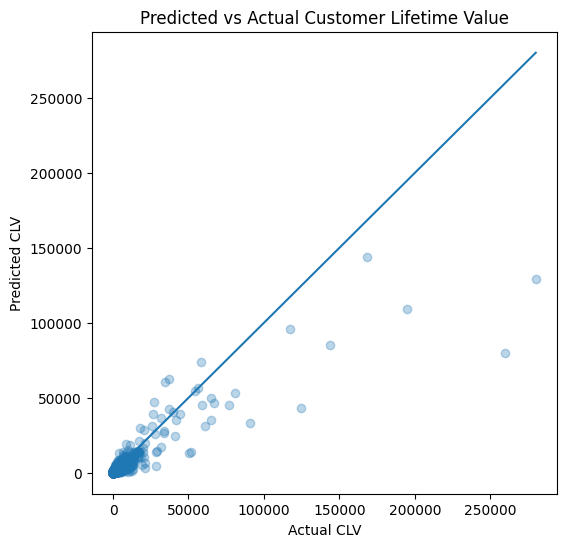

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y, preds, alpha=0.3)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Predicted vs Actual Customer Lifetime Value")

# perfect prediction line
max_val = max(y.max(), preds.max())
plt.plot([0, max_val], [0, max_val])
plt.show()

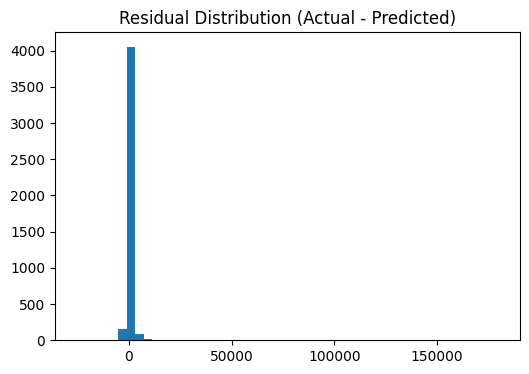

In [19]:
residuals = y - preds

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution (Actual - Predicted)")
plt.show()

In [20]:
df_eval = df.copy()
df_eval["actual_clv"] = y
df_eval["predicted_clv"] = preds

df_eval["CLV_segment"] = pd.cut(
    df_eval["actual_clv"],
    bins=[0, 500, 1500, 5000, float("inf")],
    labels=["Low", "Medium", "High", "VIP"]
)

segment_perf = df_eval.groupby("CLV_segment").agg(
    avg_actual=("actual_clv", "mean"),
    avg_pred=("predicted_clv", "mean"),
    count=("customer_id", "count")
)

segment_perf

C:\Users\sneha\AppData\Local\Temp\ipykernel_5640\2384498619.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_perf = df_eval.groupby("CLV_segment").agg(


,avg_actual,avg_pred,count
CLV_segment,,,
Low,260.187452,345.671013,1762
Medium,889.346022,881.481846,1382
High,2635.592917,2234.126671,919
VIP,17460.987345,12234.175117,275


In [21]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y, preds)
rmse = np.sqrt(mean_squared_error(y, preds))

print("Final Model Performance")
print("R²:", r2)
print("RMSE:", rmse)

Final Model Performance
R²: 0.7320454766373516
RMSE: 4652.6780032674205
